In [1]:
# standard python imports
import numpy as np
import matplotlib.pylab as plt

# tidy3D import
import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

import xarray as xr
td.config.logging_level = 'ERROR'

In [ ]:
# set up the simulation parameters

# size of simulation domain
Lx, Ly, Lz = 2, 2, 2
Lx, Ly, Lz = 1,1,1
dl = 0.06667

# waveguide information
wg_width = 0.7
wg_permittivity = 3.47**2
bg_permittivity = 1.444**2
plane_size = (4, 0, 3.5)

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

plane = td.Box(center=(0, 0, 0), size=plane_size)
mode_spec = td.ModeSpec(
    num_modes=3,
)
freqs = [freq0]

In [3]:
from typing import Literal

RunMode = Literal['local', 'remote']

def custom_medium(medium_creator):
    """
    medium custom decorator for setup_simulation func
    """
    def decorator(func):
        def wrapper(*args):
            sim = func(*args)
            if medium_creator is None:
                return sim
            creator = medium_creator(sim)
            medium, _ = creator.create()
            structures = []
            for s in sim.structures:
                structures.append(td.Structure(geometry=s.geometry, medium=medium))
        
            return sim.updated_copy(structures=structures)
        return wrapper
    return decorator

def setup_simulation(wg_width: float, grid_coefs: int, subpixel: bool):
    # automatic grid specification
    # grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)
    grid_spec = td.GridSpec.uniform(dl=dl / grid_coefs)
    mesh = td.TriangleMesh.from_stl("./wg.stl", scale=(wg_width / 0.5, 1, 1))

    waveguide = td.Structure(
        geometry=mesh,
        medium=td.Medium(permittivity=wg_permittivity),
    )
    sim = td.Simulation(
        size=(Lx, Ly, Lz),
        grid_spec=grid_spec,
        structures=[waveguide],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
        medium=td.Medium(permittivity=1.444**2),
        subpixel = subpixel
    )
    return sim

def solve_mode(sim: td.Simulation, run_remote: RunMode = 'local'):
    mode_solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=freqs,
    )
    if run_remote == 'remote':
        from tidy3d.plugins.mode.web import run as run_mode_solver
        mode_data = run_mode_solver(mode_solver)
    elif run_remote == 'local':
        mode_data = mode_solver.solve()
    return mode_data

def run_cached(*, width, grid_coefs, subpixel = False, run_remote = 'local', medium_creator = None):
    import os
    if medium_creator is not None:
        subpixel = False
        run_remote = 'local'
    cache_key = f'{grid_coefs}_subpixel-{subpixel}_{run_remote}_{width}_{medium_creator and medium_creator.__name__ or "None"}'
    file_path = './data/' + cache_key + '.hdf5'
    if os.path.isfile(file_path):
        from tidy3d.components.data.monitor_data import ModeSolverData
        return ModeSolverData.from_hdf5(file_path)
    
    sim = custom_medium(medium_creator)(setup_simulation)(width, grid_coefs, subpixel)
    data = solve_mode(sim, run_remote)
    data.to_hdf5(file_path)
    return data

In [4]:
def plot_mode_data(mode_data):
    f0_ind = 0
    f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
    abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
    abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

    ax1.set_title("|Ex(x, y)|")
    ax1.set_aspect("equal")
    ax2.set_title("|Ez(x, y)|")
    ax2.set_aspect("equal")
    plt.show()

In [ ]:
nums_width = 10
width = 0.3
widths = np.linspace(0.45, 1.0, nums_width)
widths = [0.45, 0.5, 0.55]
widths = [0.45, 0.5]
mode_data = None

coords = {'width': widths, 'label': []}
n_eff_list = []

def add_n_eff(n_eff, label):
    n_eff_list.append(n_eff)
    coords['label'].append(label)


NameError: name 'np' is not defined

1 yee, 无subpixel, local

In [ ]:
n_effs1 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=1, subpixel=False, run_remote='local')
    n_effs1.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs1, '1 yee,no subpixel,local')

1 yee, 无subpixel, remote

In [ ]:
n_effs12 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=1, subpixel=False, run_remote='remote')
    n_effs12.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs12, '1 yee,no subpixel,remote')

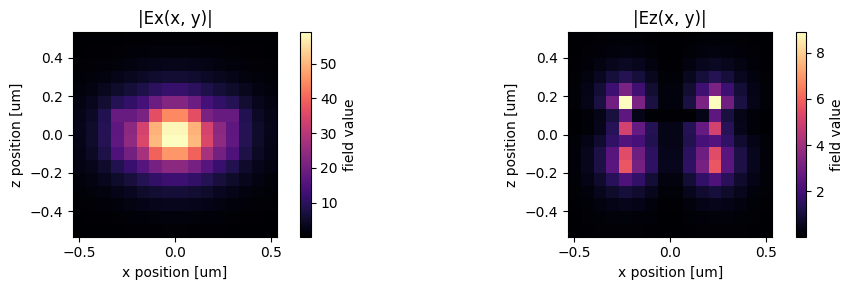

In [ ]:
f0_ind = 0
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()

local, remote 没开启subpixel，结果是一样的。remote默认总是使用subpixel

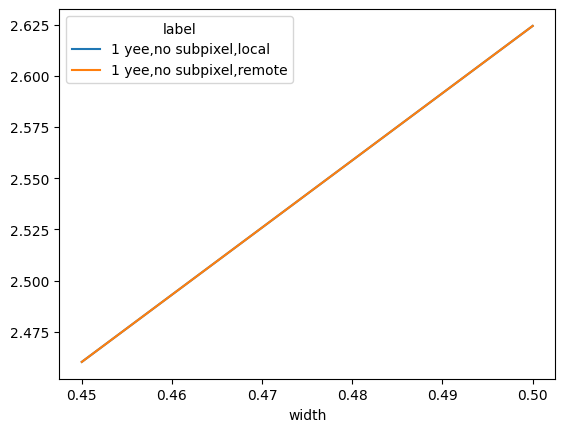

In [ ]:
n_effs = np.hstack([n_effs1, n_effs12])
xr.DataArray(n_effs, coords=coords).plot.line(x='width')

2 yee, 无subpixel, local

In [ ]:
n_effs2 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=2, subpixel=False, run_remote='local')
    n_effs2.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs2, '2 yee,no subpixel,local')


4 yee, 无subpixel, local

In [ ]:
n_effs4 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=4, subpixel=False, run_remote='local')
    n_effs4.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs4, '4 yee,no subpixel,local')

6 yee, 无subpixel, local

In [ ]:
n_effs6 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=6, subpixel=False, run_remote='local')
    n_effs6.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs6, '6 yee,no subpixel,local')

8 yee, 无subpixel, local

In [ ]:
# coords['label'].append('8 yee,no subpixel,local')

# n_effs8 = []
# for width in widths:
#     mode_data = run_cached(width=width, grid_coefs=8, subpixel=False, run_remote='local')
#     n_effs8.append(mode_data.n_eff.sel(mode_index=0).values)

1 yee, subpixel, remote

In [ ]:
n_effs13 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=1, subpixel=True, run_remote='remote')
    n_effs13.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs13, '1 yee,subpixel,remote')

[array([2.3062434], dtype=float32), array([2.424062], dtype=float32)]


2 yee, subpixel, remote

In [ ]:
# coords['label'].append('2 yee,subpixel,remote')

# n_effs23 = []
# for width in widths:
#     mode_data = run_cached(width=width, grid_coefs=2, subpixel=True, run_remote='remote')
#     n_effs23.append(mode_data.n_eff.sel(mode_index=0).values)

4 yee, subpixel, remote

In [ ]:
n_effs43 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=4, subpixel=True, run_remote='remote')
    n_effs43.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs43, '4 yee,subpixel,remote')

[array([2.2898026], dtype=float32), array([2.3908103], dtype=float32)]


6 yee, subpixel, remote

In [ ]:
# coords['label'].append('6 yee,subpixel,remote')

# n_effs63 = []
# for width in widths:
#     mode_data = run_cached(width=width, grid_coefs=6, subpixel=True, run_remote='remote')
#     n_effs63.append(mode_data.n_eff.sel(mode_index=0).values)

1 yee,custom subpixel,local

In [ ]:
import custom.spatial_medium as sm
# n_effs14 = []
# for width in widths:
#     mode_data = run_cached(width=width, grid_coefs=1, medium_creator=sm.SpatialMediumCreator3)
#     n_effs14.append(mode_data.n_eff.sel(mode_index=0).values)

# add_n_eff(n_effs14, '1 yee,custom subpixel,local')

1 yee, 2x custom subpixel, local

In [ ]:
import custom.spatial_medium as sm
sm.SpatialMediumCreator5.MAX_ITERATIONS = 5
n_effs142 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=1, medium_creator=sm.SpatialMediumCreator5)
    n_effs142.append(mode_data.n_eff.sel(mode_index=0).values)


add_n_eff(n_effs142, '1 yee,2x custom subpixel,local')

[array([2.2152243], dtype=float32), array([2.3293183], dtype=float32)]


In [ ]:
import custom.spatial_medium as sm
n_effs144 = []
for width in widths:
    mode_data = run_cached(width=width, grid_coefs=1, medium_creator=sm.SpatialMediumCreator6)
    n_effs144.append(mode_data.n_eff.sel(mode_index=0).values)

add_n_eff(n_effs144, '1 yee,4x custom subpixel,local')

[array([2.321128], dtype=float32), array([2.446238], dtype=float32)]


plot the graph

<xarray.DataArray (width: 2, label: 9)> Size: 72B
array([[2.460225 , 2.4602258, 2.369417 , 2.2901292, 2.2641108, 2.3062434,
        2.2898026, 2.2152243, 2.321128 ],
       [2.6244285, 2.6244295, 2.4652417, 2.3882048, 2.3650036, 2.424062 ,
        2.3908103, 2.3293183, 2.446238 ]], dtype=float32)
Coordinates:
  * width    (width) float64 16B 0.45 0.5
  * label    (label) <U30 1kB '1 yee,no subpixel,local' ... '1 yee,4x custom ...


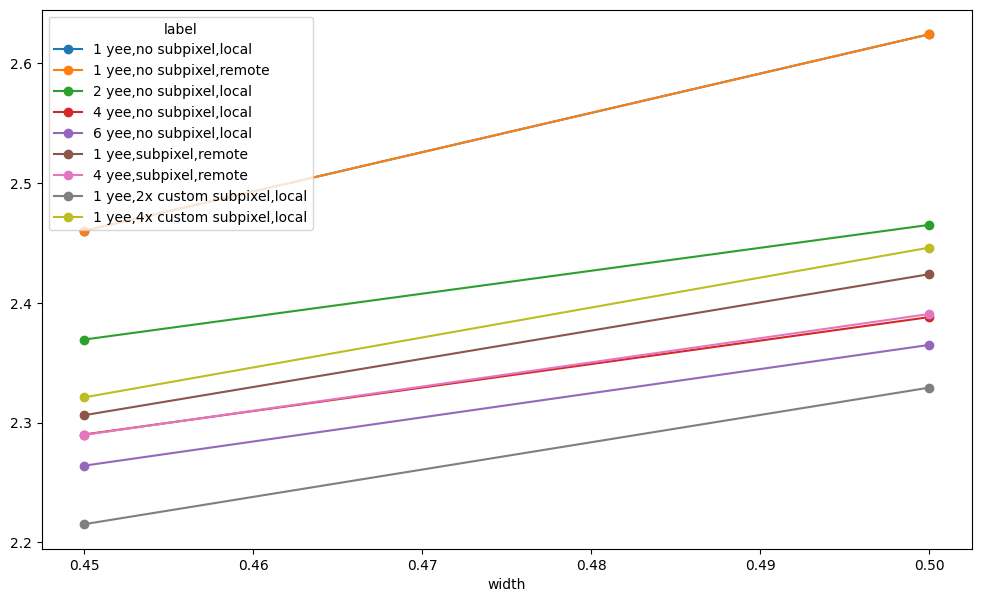

In [ ]:
n_effs = np.hstack(n_eff_list)
plt.figure(figsize=(12,7))
# xr.DataArray(n_effs, coords=coords).plot.line(x='width', yticks=np.arange(2.0, 2.3, 0.2), ylim=(2.0, 2.5))
xr.DataArray(n_effs, coords=coords).plot.line(x='width', marker='o')

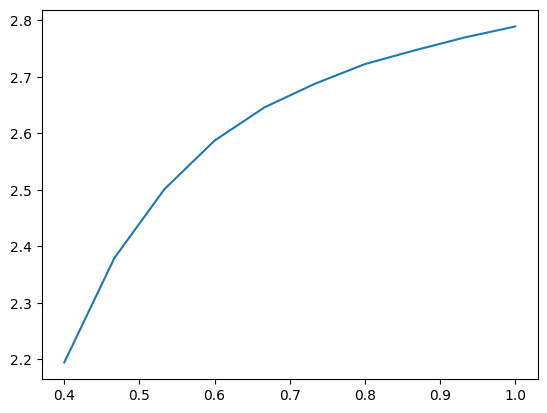

In [ ]:
# plot n_effs2 individually
plt.plot(widths, n_effs2)
# plt.plot(widths, n_effs4) # n_effs4 is the same as n_effs2
